# Inference & Evaluation Notebook

This notebook provides a comprehensive evaluation pipeline for Siamese neural networks trained with different loss functions (MS, Contrastive, Circle) on face verification tasks. It includes:
- 1. Loading and evaluating trained models with various loss types.
- 2. Loading an arbitray dataset
- 3. Calculation and visualization of intra- and inter-class distances.
- 4. Computation of evaluation metrics (accuracy, precision, recall, F1, AUROC, AUPRC) and confusion matrices.
- 5. Pairwise Confusion Metrics.

Use this notebook to analyze and compare the discriminative power of different loss functions for face similarity tasks.

### Library Import

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import numpy as np
import torch
from src.preprocessing.dataLoader_Siamase import SiameseNetworkDataset
from src.ml.resNet18 import SiameseNetworkCosine, SiameseNetworkContrastive
from collections import defaultdict
from itertools import combinations
import torch
import torch.nn.functional as F
import pandas as pd
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
import torch
import torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_curve, auc, average_precision_score,
    confusion_matrix, accuracy_score, f1_score,
    precision_score, recall_score
)
import random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from PIL import Image
from collections import defaultdict
import src.inference_utils.utils as utils

### Dataset Selection

This notebook uses the `dataset_name` variable to specify which dataset to work with. The available options are:

- `"CelebA"` — Large-scale face dataset with celebrity images.
- `"VGGface"` — High-quality face dataset used for face recognition tasks.
- `"AT&T"` — Small grayscale face dataset with multiple subjects.


In [2]:
DATASET_NAME = "AT&T"

### Seed a unique number to reproduce our experiments

In [3]:
g = torch.Generator()
g.manual_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load all Networks
- Contrastive network
- Multi-similarity network
- Circle network

In [4]:
import warnings
warnings.filterwarnings('ignore')
# Load the Contrastive loss model
model_path = "models/models_contrastive/best_model_overall.pt"
net_contrastive = SiameseNetworkContrastive().to(DEVICE)
net_contrastive.load_state_dict(torch.load(model_path, map_location=DEVICE), strict=False)

# Load the MS loss model
model_path = "models/models_ms/models_ms_40_80/best_model_overall.pt"
net_ms = SiameseNetworkCosine().to(DEVICE)
net_ms.load_state_dict(torch.load(model_path, map_location=DEVICE), strict=False)

# Load the Circle loss model
model_path = "models/models_circle/best_model_overall.pt"
net_circle = SiameseNetworkCosine().to(DEVICE)
net_circle.load_state_dict(torch.load(model_path, map_location=DEVICE), strict=False)

<All keys matched successfully>

In [5]:
model_paths = {
    "Contrastive":  net_contrastive,
    "MS-Loss":      net_ms,
    "Circle-Loss":  net_circle
}

# 2. Load the Test Dataset

In [6]:
# Your transformations and dataset
transformation_test = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

root = f"dataset/test/{DATASET_NAME}/"
folder_dataset_test = datasets.ImageFolder(root=root)
test_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset_test,
                                     transform=transformation_test)

test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=0, generator=g)

# 3. Calculation and visualization of intra- and inter-class distances.

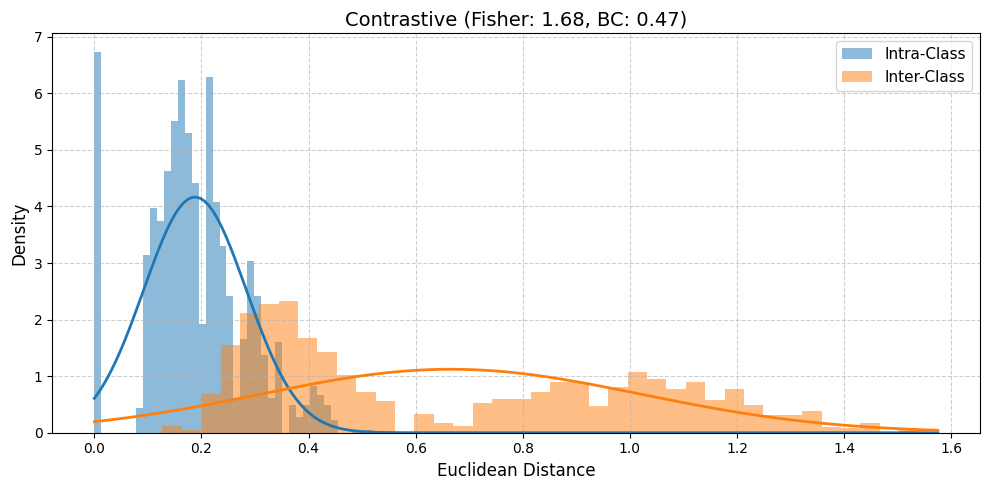

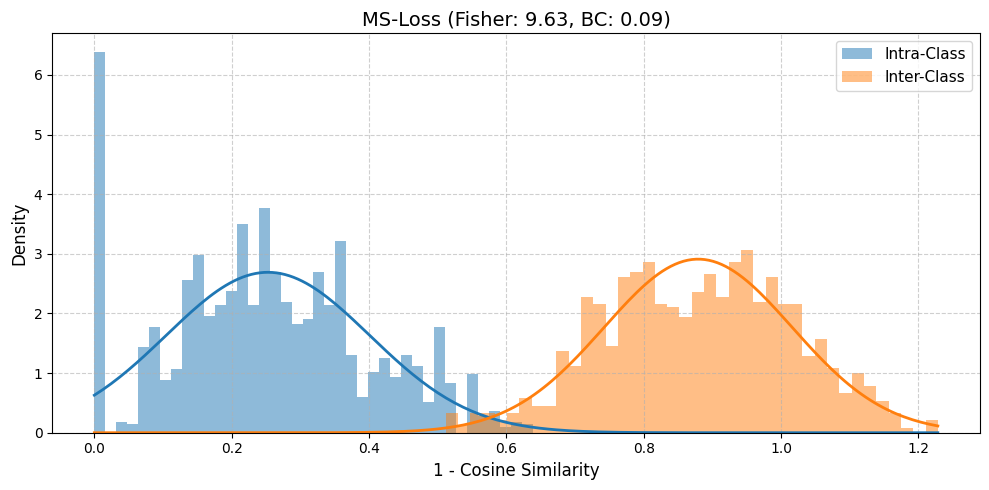

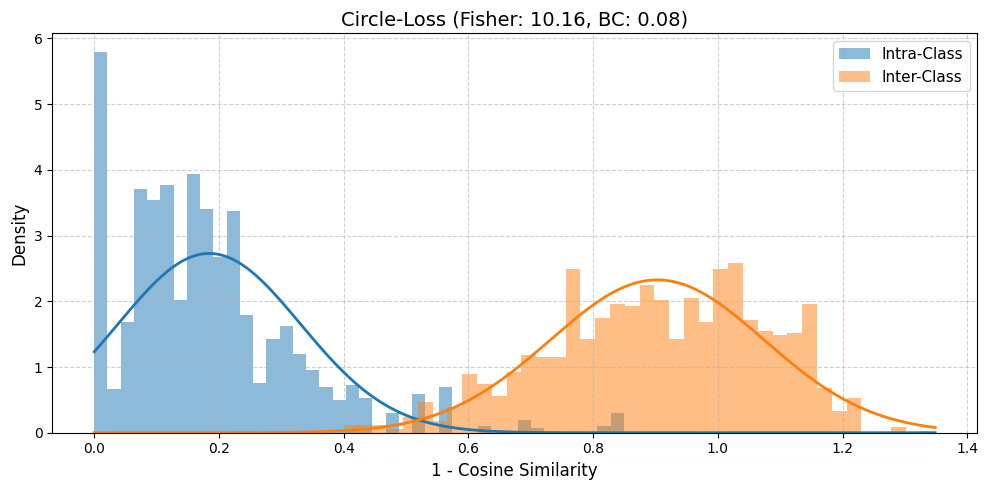

             mu_intra  mu_inter  sd_intra  sd_inter     fisher  bhattacharyya
Contrastive  0.187945  0.665485  0.095752  0.355516   1.682245       0.465377
MS-Loss      0.252748  0.879191  0.148270  0.137035   9.627241       0.089963
Circle-Loss  0.184463  0.902713  0.146213  0.171496  10.157357       0.078420
Best model by Fisher-Ratio: Circle-Loss


In [7]:
np.random.seed(42)
results = {}

# Evaluate each model
for name, model in model_paths.items():
    intra_d, inter_d, xlabel = utils.compute_intra_inter(test_dataloader, model, name)
    metrics = utils.separation_metrics(intra_d, inter_d)
    results[name] = metrics

    # Plot histogram with Gaussian fit
    plt.figure(figsize=(10, 5))
    plt.hist(intra_d, bins=40, density=True, alpha=0.5, color='C0', label='Intra-Class')
    plt.hist(inter_d, bins=40, density=True, alpha=0.5, color='C1', label='Inter-Class')

    xmin = min(intra_d.min(), inter_d.min())
    xmax = max(intra_d.max(), inter_d.max())
    x = np.linspace(xmin, xmax, 200)

    mu_in, sd_in = metrics['mu_intra'], metrics['sd_intra']
    mu_it, sd_it = metrics['mu_inter'], metrics['sd_inter']
    pdf_in = (1 / (sd_in * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu_in) / sd_in) ** 2)
    pdf_it = (1 / (sd_it * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu_it) / sd_it) ** 2)

    plt.plot(x, pdf_in, color='C0', linewidth=2)
    plt.plot(x, pdf_it, color='C1', linewidth=2)

    plt.title(f"{name} (Fisher: {metrics['fisher']:.2f}, BC: {metrics['bhattacharyya']:.2f})", fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()

# Create summary table
df = pd.DataFrame(results).T
print(df[['mu_intra', 'mu_inter', 'sd_intra', 'sd_inter', 'fisher', 'bhattacharyya']])

# Select best model based on Fisher Ratio
best_fisher = max(results.items(), key=lambda x: x[1]['fisher'])
print(f"Best model by Fisher-Ratio: {best_fisher[0]}")


# 4. AUROC and Evaluation Metrics

In [8]:
fold_seeds = list(range(99))
fold_results = []
for seed in fold_seeds:
    g = torch.Generator().manual_seed(seed)
    loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                        num_workers=0, generator=g)
    one_fold = utils.evaluate_models(model_paths, loader, DEVICE,
                               show_plot=False, show_cm=False)
    one_fold['fold'] = seed
    fold_results.append(one_fold)
cv_results = pd.concat(fold_results)


summary = (
    cv_results.reset_index()
              .groupby('model')
              .agg(['mean','std'])
              .round(3)
)
display(summary)


g0 = torch.Generator().manual_seed(0)
fixed_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                          num_workers=0, generator=g0)
fixed_pairs = [
    (i1.to(DEVICE), i2.to(DEVICE), lb.to(DEVICE))
    for i1, i2, lb, *_ in fixed_loader
]
summary_fixed = utils.evaluate_models_fixed(model_paths, fixed_pairs,
                                      show_plot=True, show_cm=True)
display(summary_fixed)


mean_summary = summary.xs('mean', axis=1, level=1)[['accuracy','precision','recall','F1']]

utils.plot_grouped_metrics(mean_summary)

KeyboardInterrupt: 

# 5. Pairwise Confusion Metrics.

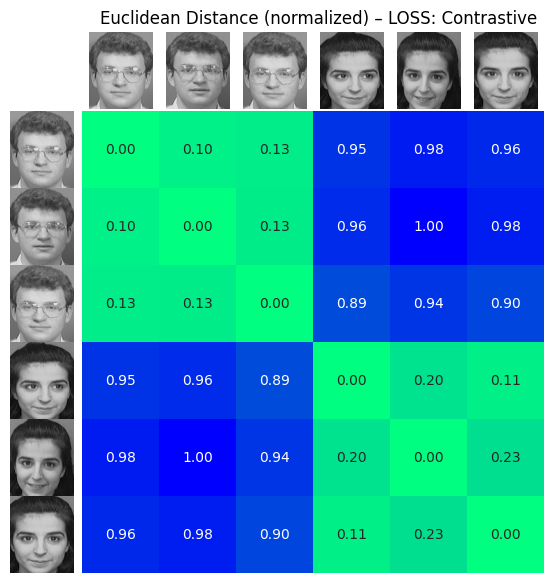

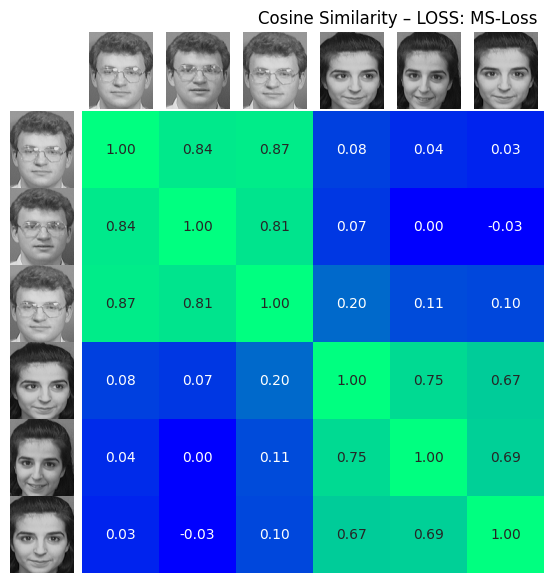

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x75697f403230>>
Traceback (most recent call last):
  File "/home/arman/.conda/envs/RAML/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


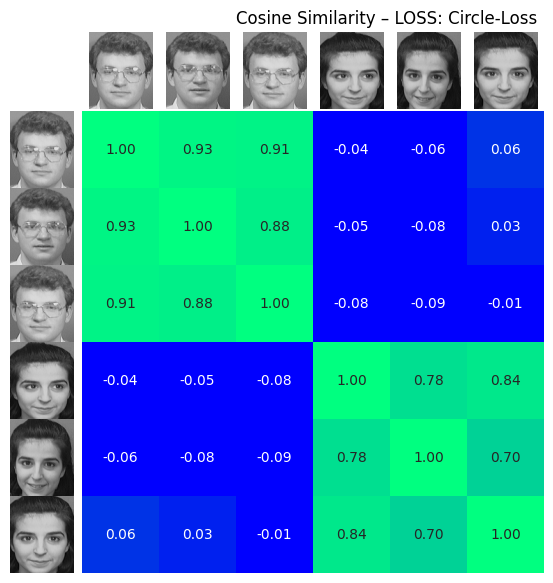

In [11]:

orig_cmap    = plt.colormaps.get_cmap("winter")
gamma        = 0.55
colors       = orig_cmap(np.linspace(0, 1, 256) ** gamma)
blue2green   = mcolors.ListedColormap(colors)
blue2green_r = blue2green.reversed()  # invertiertes Colormap



cls2paths = defaultdict(list)
for path, lbl in folder_dataset_test.imgs:
    cls2paths[lbl].append(path)
valid_classes = [c for c,lst in cls2paths.items() if len(lst) >= 3]
assert len(valid_classes) >= 2, "Need ≥2 classes with ≥5 images each!"

cls_a, cls_b = random.sample(valid_classes, 2)
paths = random.sample(cls2paths[cls_a], 3) + random.sample(cls2paths[cls_b], 3)
pil_images = [Image.open(p).convert("RGB") for p in paths]


for name, net in model_paths.items():
    net.eval()

    # Embeddings berechnen
    with torch.no_grad():
        batch = torch.stack([transformation_test(im) for im in pil_images]).to(DEVICE)
        embeddings = net.forward_once(batch)

    # Matrix & Label
    matrix, metric_label, is_dist = utils.compute_matrix(embeddings, name)

    # Plot erzeugen
    fig = plt.figure(figsize=(6, 6))
    ax  = sns.heatmap(
        matrix,
        cmap=blue2green_r if is_dist else blue2green,
        vmin=0, vmax=1,
        square=True,
        annot=True, fmt=".2f",
        cbar=False,
        xticklabels=False, yticklabels=False
    )
    utils.add_thumbnails(ax, pil_images, side="left")
    utils.add_thumbnails(ax, pil_images, side="top")
    plt.title(f"{metric_label} – LOSS: {name}", fontsize=12, loc="right")
    plt.show()